# **Image Query System - Moteur de Recherche Visuel**

## **_Phase 1_***: Acquisition et préparation des données*

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
from torchvision import transforms


## 1. Chargement des données

In [6]:
# Chemin 
DATA_DIR  = r"../data/clothing-dataset"

# Chemin trainset
TRAIN_DIR = os.path.join(DATA_DIR, "train")
# Chemin testset
TEST_DIR  = os.path.join(DATA_DIR, "test")

## 2. Analyse Exploratoire (EDA)
### 2.1 Distribution des classes

Nombre de classes : 10
Total images train : 3068

 dress : 241 images
 hat : 123 images
 longsleeve : 455 images
 outwear : 184 images
 pants : 468 images
 shirt : 290 images
 shoes : 198 images
 shorts : 202 images
 skirt : 112 images
 t-shirt : 795 images


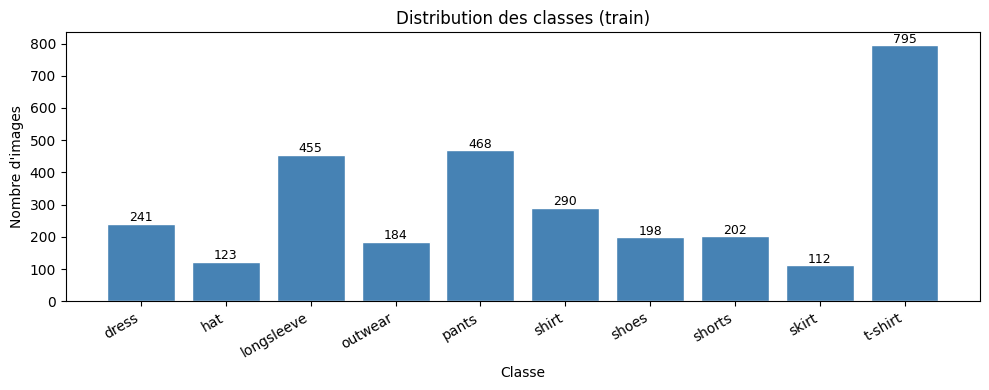

In [7]:
classes = sorted(os.listdir(TRAIN_DIR))
counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in classes]

print(f"Nombre de classes : {len(classes)}")
print(f"Total images train : {sum(counts)}\n")

for cls, n in zip(classes, counts):
    print(f" {cls} : {n} images")

# Visualisation de la distribution
plt.figure(figsize=(10, 4))
bars = plt.bar(classes, counts, color="steelblue", edgecolor="white")
plt.title("Distribution des classes (train)")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=30, ha="right")

for bar, n in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             str(n), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../results/distribution_classes.png", dpi=150)
plt.show()

### 2.2 Tailles des images

Largeur -- min: 400, max: 888, moy: 425
Hauteur -- min: 400, max: 936, moy: 517
Images analysées : 3068


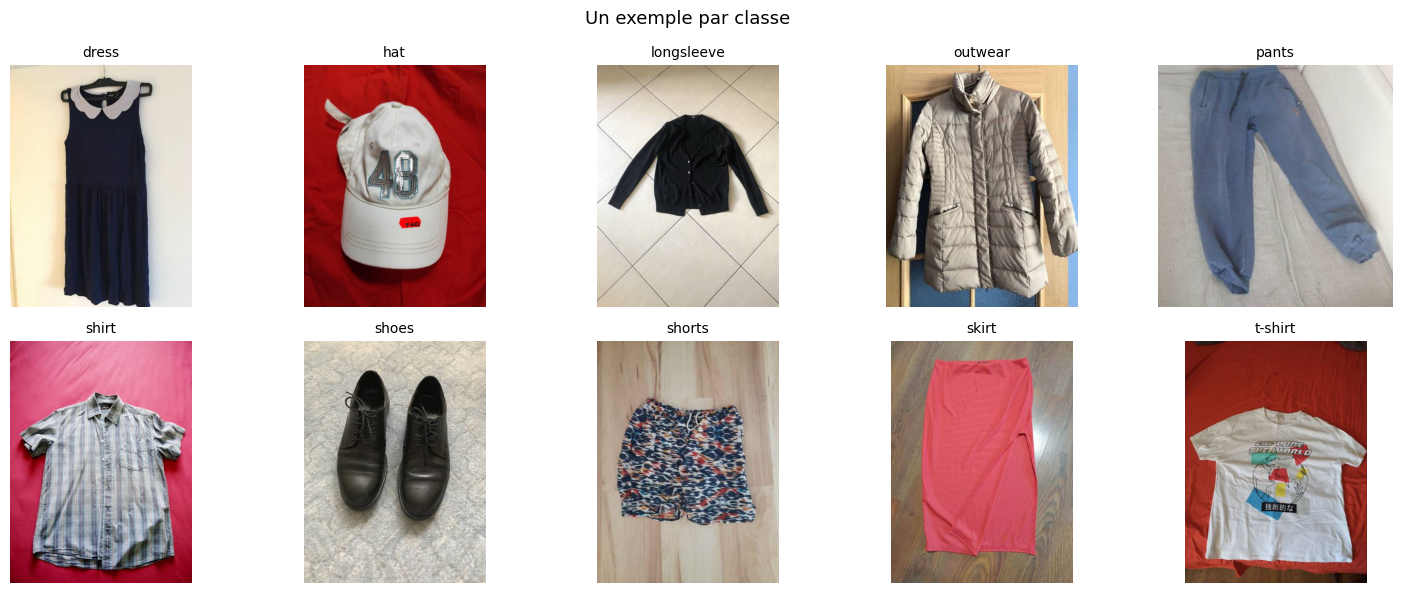

In [8]:
widths, heights = [], []

for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir):
        try:
            w, h = Image.open(os.path.join(cls_dir, fname)).size
            widths.append(w)
            heights.append(h)
        except:
            pass

print(f"Largeur -- min: {min(widths)}, max: {max(widths)}, moy: {int(np.mean(widths))}")
print(f"Hauteur -- min: {min(heights)}, max: {max(heights)}, moy: {int(np.mean(heights))}")
print(f"Images analysées : {len(widths)}")

# Exemples visuels par classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Un exemple par classe", fontsize=13)

for ax, cls in zip(axes.flat, classes):
    img_path = os.path.join(TRAIN_DIR, cls,
                os.listdir(os.path.join(TRAIN_DIR, cls))[0])
    ax.imshow(Image.open(img_path))
    ax.set_title(cls, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../results/exemples_classes.png", dpi=150)
plt.show()

## 3. Nettoyage 

In [9]:
# Détection des fichiers corrompus
corrompus = []

for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        try:
            img = Image.open(fpath)
            img.verify()  # vérifie l'intégrité sans charger en mémoire
        except Exception as e:
            corrompus.append((fpath, str(e)))

print(f"Fichiers corrompus détectés : {len(corrompus)}")
for path, err in corrompus:
    print(f"  {path} -> {err}")

Fichiers corrompus détectés : 0


## 4. Vérification du split train / validation / test

In [10]:
VAL_DIR = os.path.join(DATA_DIR, "validation")

splits = {"train": TRAIN_DIR, "validation": VAL_DIR, "test": TEST_DIR}

print(f"{'Classe'} -   {'Train'} - {'Val'} - {'Test'} - {'Total'}")


for cls in classes:
    counts_split = []
    for split, d in splits.items():
        cls_dir = os.path.join(d, cls)
        n = len(os.listdir(cls_dir)) if os.path.exists(cls_dir) else 0
        counts_split.append(n)
    total = sum(counts_split)
    print(f"{cls} -  {counts_split[0]} - {counts_split[1]} - {counts_split[2]} - {total}")


totaux = []
for split, d in splits.items():
    t = sum(len(os.listdir(os.path.join(d, c)))
            for c in classes if os.path.exists(os.path.join(d, c)))
    totaux.append(t)
print(f"{'TOTAL'} -   {totaux[0]} - {totaux[1]} - {totaux[2]} - {sum(totaux)}")

Classe -   Train - Val - Test - Total
dress -  241 - 32 - 15 - 288
hat -  123 - 14 - 12 - 149
longsleeve -  455 - 49 - 72 - 576
outwear -  184 - 24 - 38 - 246
pants -  468 - 49 - 42 - 559
shirt -  290 - 29 - 26 - 345
shoes -  198 - 26 - 73 - 297
shorts -  202 - 25 - 30 - 257
skirt -  112 - 12 - 12 - 136
t-shirt -  795 - 81 - 52 - 928
TOTAL -   3068 - 341 - 372 - 3781


## 5. Construction de la liste d'indexation

In [11]:
def build_image_list(root_dir, classes):
    records = []
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            records.append({
                "path"  : os.path.join(cls_dir, fname),
                "label" : cls
            })
    return pd.DataFrame(records)

df_train = build_image_list(TRAIN_DIR, classes)
df_val = build_image_list(VAL_DIR, classes)
df_test = build_image_list(TEST_DIR, classes)

print(f"Train : {len(df_train)} images")
print(f"Val : {len(df_val)} images")
print(f"Test : {len(df_test)} images")
print(f"\nAperçu :")
print(df_train.head())


# Sauvegarde des listes d'images
df_train.to_csv("../results/train_list.csv", index=False)
df_val.to_csv("../results/val_list.csv", index=False)
df_test.to_csv("../results/test_list.csv", index=False)

print()
print("Listes sauvegardées dans results/")

Train : 3068 images
Val : 341 images
Test : 372 images

Aperçu :
                                                path  label
0  ../data/clothing-dataset\train\dress\009b3c31-...  dress
1  ../data/clothing-dataset\train\dress\041c6bde-...  dress
2  ../data/clothing-dataset\train\dress\04f0b07f-...  dress
3  ../data/clothing-dataset\train\dress\053689bb-...  dress
4  ../data/clothing-dataset\train\dress\0546d34a-...  dress

Listes sauvegardées dans results/


## 6. Preprocessing : redimensionnement uniforme (224x224), normalisation des pixels

Taille originale : (400, 533)
Taille après resize : torch.Size([3, 224, 224])
Min pixel : -1.930
Max pixel : 2.605


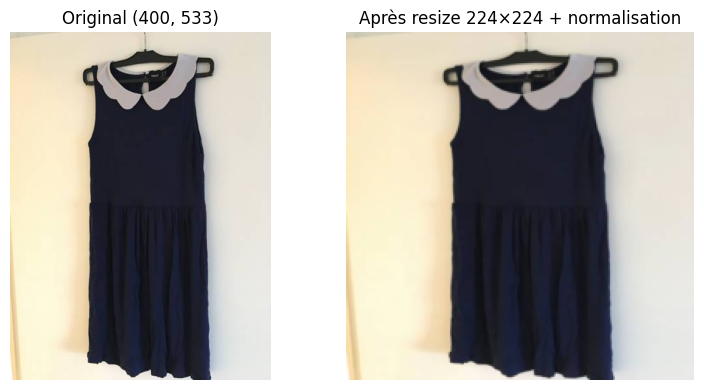

In [12]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Vérification sur un échantillon
sample_path = df_train.iloc[0]["path"]
img_pil = Image.open(sample_path).convert("RGB")
img_tensor  = transform(img_pil)

print(f"Taille originale : {img_pil.size}")
print(f"Taille après resize : {img_tensor.shape}")
print(f"Min pixel : {img_tensor.min():.3f}")
print(f"Max pixel : {img_tensor.max():.3f}")


# Visualisation avant / après
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img_pil)
axes[0].set_title(f"Original {img_pil.size}")
axes[0].axis("off")

# Dénormalisation pour affichage
img_display = img_tensor.permute(1, 2, 0).numpy()
img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_display = np.clip(img_display, 0, 1)

axes[1].imshow(img_display)
axes[1].set_title("Après resize 224×224 + normalisation")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../results/preprocessing_exemple.png", dpi=150)
plt.show()

## **_Phase 2_***: Service d'encodage d'images*

## 1. Test d'encodeurs

In [14]:
import sys
import os
sys.path.append("..")
import importlib
import src.encoders
importlib.reload(src.encoders)
from src.encoders import ResNetEncoder, CLIPEncoder, AutoencoderEncoder
from torch.utils.data import Dataset, DataLoader
from src.utils import transform_standard
import torch
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

c:\Users\USER\Documents\GitHub\ImageQuerySystem\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
# Test ResNet-50
print("Chargement ResNet-50...")
resnet_enc = ResNetEncoder()
emb_resnet  = resnet_enc.encode(sample_path)

print(f"Dimension embedding ResNet : {emb_resnet.shape}")
print(f"Min : {emb_resnet.min():.4f} | Max : {emb_resnet.max():.4f}")


Chargement ResNet-50...
Dimension embedding ResNet : torch.Size([2048])
Min : 0.0000 | Max : 3.7685


In [19]:
# Test CLIP
print("Chargement CLIP...")
clip_enc = CLIPEncoder()
emb_clip  = clip_enc.encode(sample_path)

print(f"Dimension embedding CLIP : {emb_clip.shape}")
print(f"Min : {emb_clip.min():.4f} | Max : {emb_clip.max():.4f}")

Chargement CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 11736.69it/s]


Dimension embedding CLIP : torch.Size([768])
Min : -4.7747 | Max : 3.5938


In [17]:
# Test Autoencoder (sans entraînement, poids aléatoires)
print("Chargement Autoencoder...")
ae_enc  = AutoencoderEncoder()
emb_ae  = ae_enc.encode(sample_path)

print(f"Dimension embedding AE : {emb_ae.shape}")
print(f"Min : {emb_ae.min():.4f} | Max : {emb_ae.max():.4f}")

Chargement Autoencoder...
Dimension embedding AE : torch.Size([50176])
Min : 0.0000 | Max : 0.2440


### **Résumé**

In [20]:
# Résumé comparatif
print("Résumé des encodeurs :")
print(f" ResNet-50 : {emb_resnet.shape[0]} dimensions")
print(f" CLIP : {emb_clip.shape[0]} dimensions")
print(f" Autoencoder : {emb_ae.shape[0]} dimensions")

Résumé des encodeurs :
 ResNet-50 : 2048 dimensions
 CLIP : 768 dimensions
 Autoencoder : 50176 dimensions


## 2. Entrainement de l'Autoencodeur

In [66]:
class ClothingDataset(Dataset):
    def __init__(self, df):
        self.paths = df["path"].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return transform_standard(img)

train_dataset = ClothingDataset(df_train)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Batches : {len(train_loader)}")
print(f"Début de l'entraînement...")

history = ae_enc.train_model(train_loader, epochs=20, lr=5e-4)

Batches : 96
Début de l'entraînement...
Epoch 1/20 — Loss: 0.5855
Epoch 2/20 — Loss: 0.5774
Epoch 3/20 — Loss: 0.5769
Epoch 4/20 — Loss: 0.5766
Epoch 5/20 — Loss: 0.5763
Epoch 6/20 — Loss: 0.5760
Epoch 7/20 — Loss: 0.5758
Epoch 8/20 — Loss: 0.5755
Epoch 9/20 — Loss: 0.5754
Epoch 10/20 — Loss: 0.5750
Epoch 11/20 — Loss: 0.5744
Epoch 12/20 — Loss: 0.5742
Epoch 13/20 — Loss: 0.5738
Epoch 14/20 — Loss: 0.5735
Epoch 15/20 — Loss: 0.5733
Epoch 16/20 — Loss: 0.5730
Epoch 17/20 — Loss: 0.5726
Epoch 18/20 — Loss: 0.5721
Epoch 19/20 — Loss: 0.5721
Epoch 20/20 — Loss: 0.5718


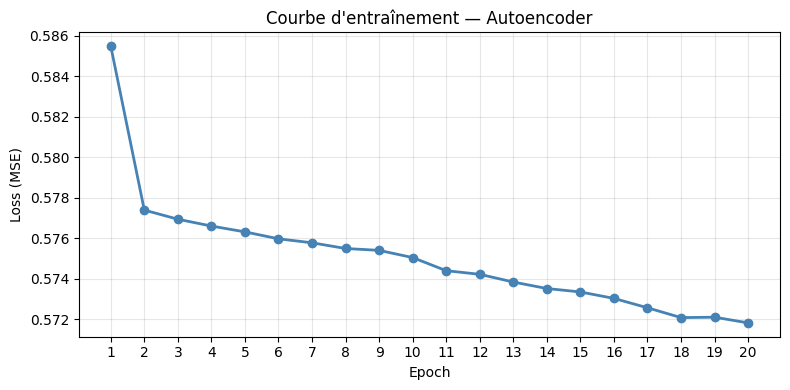

In [67]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history)+1), history, marker="o", color="steelblue", linewidth=2)
plt.title("Courbe d'entraînement — Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.xticks(range(1, len(history)+1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/autoencoder_training_curve.png", dpi=150)
plt.show()

In [21]:
# Sauvegarde des poids de l'Autoencoder
os.makedirs("../models", exist_ok=True)
torch.save(ae_enc.model.state_dict(), "../models/autoencoder.pth")
print("Poids sauvegardés dans models/autoencoder.pth")

Poids sauvegardés dans models/autoencoder.pth


## 3. Comparaison

In [22]:
# Comparaison qualitative sur 5 images
samples = df_train.groupby("label").first().reset_index()["path"].tolist()[:5]

print(f"{'Image'} | {'ResNet'} | {'CLIP'} | {'AE'}")
for path in samples:
    label = os.path.basename(os.path.dirname(path))
    r = resnet_enc.encode(path)
    c = clip_enc.encode(path)
    a = ae_enc.encode(path)
    print(f"{label} | {r.norm():.4f} | {c.norm():.4f} | {a.norm():.4f}")

Image | ResNet | CLIP | AE
dress | 10.7137 | 25.7617 | 9.2146
hat | 10.2888 | 26.1221 | 8.2920
longsleeve | 17.1123 | 26.5595 | 8.6710
outwear | 10.3252 | 26.2529 | 6.7943
pants | 10.4581 | 26.9739 | 6.3309


## 4. Visualisation t-SNE des 3 encodeurs

In [23]:
#  Échantillon : 30 images par classe
samples = []
for cls in classes:
    cls_df = df_train[df_train["label"] == cls].sample(min(30, len(df_train[df_train["label"] == cls])), random_state=42)
    samples.append(cls_df)

sample_df = pd.concat(samples).reset_index(drop=True)

print(f"Échantillon : {len(sample_df)} images")
print(sample_df["label"].value_counts())

paths  = sample_df["path"].tolist()
labels = sample_df["label"].tolist()

print("\nGénération des embeddings ResNet...")
embs_resnet = resnet_enc.encode_batch(paths).numpy()

print("Génération des embeddings CLIP...")
embs_clip = clip_enc.encode_batch(paths).numpy()

print("Génération des embeddings AE...")
embs_ae = ae_enc.encode_batch(paths).numpy()

print("Effectué.")

Échantillon : 300 images
label
dress         30
hat           30
longsleeve    30
outwear       30
pants         30
shirt         30
shoes         30
shorts        30
skirt         30
t-shirt       30
Name: count, dtype: int64

Génération des embeddings ResNet...
Génération des embeddings CLIP...
Génération des embeddings AE...
Effectué.


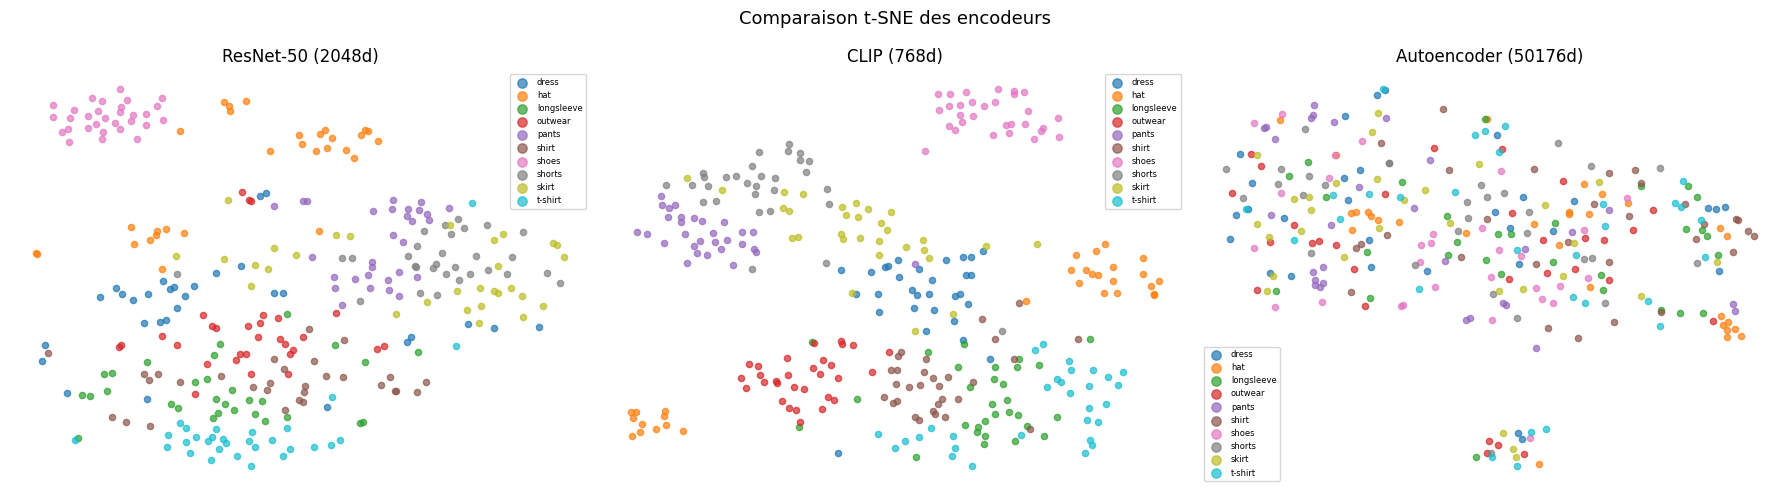

In [72]:
# t-SNE sur les 3 encodeurs
def plot_tsne(embeddings, labels, title, ax):
    tsne = TSNE(n_components=2, random_state=42, perplexity=20)
    coords = tsne.fit_transform(embeddings)
    classes_uniq = sorted(set(labels))
    colors = plt.cm.tab10(range(len(classes_uniq)))
    for cls, col in zip(classes_uniq, colors):
        idx = [i for i, l in enumerate(labels) if l == cls]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   label=cls, color=col, s=20, alpha=0.7)
    ax.set_title(title)
    ax.legend(fontsize=6, markerscale=1.5)
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_tsne(embs_resnet, labels, "ResNet-50 (2048d)",  axes[0])
plot_tsne(embs_clip, labels, "CLIP (768d)", axes[1])
plot_tsne(embs_ae, labels, "Autoencoder (50176d)", axes[2])

plt.suptitle("Comparaison t-SNE des encodeurs", fontsize=13)
plt.tight_layout()
plt.savefig("../results/tsne_comparaison.png", dpi=150)
plt.show()

## _**Phase 3** : Construction du système de requête_

## 1. Génération des embeddings

In [24]:
from tqdm import tqdm
import faiss

In [25]:
# On utilise CLIP comme encodeur principal
print(f"Génération des embeddings pour {len(df_train)} images...")

all_embeddings = []
all_paths = []
all_labels = []

for i, row in tqdm(df_train.iterrows(), total=len(df_train)):
    emb = clip_enc.encode(row["path"])
    all_embeddings.append(emb.numpy())
    all_paths.append(row["path"])
    all_labels.append(row["label"])

embeddings_matrix = np.array(all_embeddings).astype("float32")

print(f"Matrice d'embeddings : {embeddings_matrix.shape}")
print(f"Type : {embeddings_matrix.dtype}")

Génération des embeddings pour 3068 images...


 19%|█▉        | 579/3068 [00:58<03:58, 10.44it/s]c:\Users\USER\Documents\GitHub\ImageQuerySystem\env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
100%|██████████| 3068/3068 [05:06<00:00

Matrice d'embeddings : (3068, 768)
Type : float32


In [26]:
# Sauvegarde des embeddings
os.makedirs("../data/embeddings", exist_ok=True)
np.save("../data/embeddings/clip_embeddings.npy", embeddings_matrix)
np.save("../data/embeddings/clip_labels.npy", np.array(all_labels))

with open("../data/embeddings/clip_paths.txt", "w") as f:
    f.write("\n".join(all_paths))

print("Embeddings sauvegardés dans data/embeddings/")

Embeddings sauvegardés dans data/embeddings/


## 2. Construction de l'index FAISS

In [27]:
dimension = embeddings_matrix.shape[1]  # 768

# Normalisation L2 pour similarité cosinus
faiss.normalize_L2(embeddings_matrix)

# Index FlatL2 : exact, adapté à notre taille de base (3068 images)
index = faiss.IndexFlatL2(dimension)
index.add(embeddings_matrix)

print(f"Index FAISS construit")
print(f"Dimension : {dimension}")
print(f"Nombre de vecteurs indexés : {index.ntotal}")

Index FAISS construit
Dimension : 768
Nombre de vecteurs indexés : 3068


In [28]:
# Sauvegarde de l'index
faiss.write_index(index, "../data/embeddings/clip_faiss.index")
print("Index sauvegardé dans data/embeddings/clip_faiss.index")

Index sauvegardé dans data/embeddings/clip_faiss.index


## 3. Fonction de requête Top-K

Retourne les K images les plus similaires à l'image requête

In [ ]:
def search(query_path, k=5):
    # Encoder l'image requête
    query_emb = clip_enc.encode(query_path).numpy().reshape(1, -1).astype("float32")
    faiss.normalize_L2(query_emb)

    # Recherche dans l'index
    distances, indices = index.search(query_emb, k+1)  # k+1 pour exclure l'image elle-même

    # Exclure l'image requête si elle est dans la base
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if all_paths[idx] != query_path:
            results.append({
                "path" : all_paths[idx],
                "label" : all_labels[idx],
                "distance": float(dist)
            })
    return results[:k]

In [31]:
# Test de la fonction de requête
query_path = df_train.iloc[0]["path"]
results = search(query_path, k=5)

print(f"Requête : {all_labels[0]} - {query_path}")
print(f"\nTop-5 résultats :")
for i, r in enumerate(results):
    print(f" {i+1}. {r['label']} - distance: {r['distance']:.4f}")

Requête : dress - ../data/clothing-dataset\train\dress\009b3c31-fb62-45c0-be9a-37a5c238cb88.jpg

Top-5 résultats :
 1. dress - distance: 0.2542
 2. dress - distance: 0.2670
 3. dress - distance: 0.2877
 4. dress - distance: 0.3017
 5. dress - distance: 0.3039


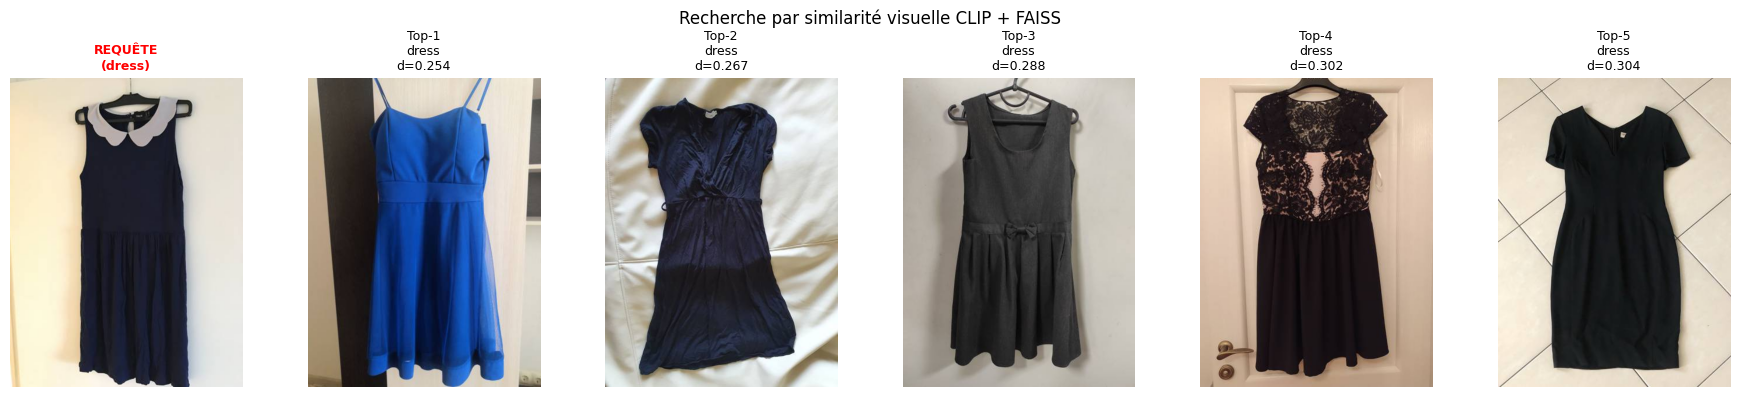

In [32]:
# Visualisation de la requête et des résultats
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# Image requête
axes[0].imshow(Image.open(query_path))
axes[0].set_title("REQUÊTE\n(dress)", fontsize=9, color="red", fontweight="bold")
axes[0].axis("off")

# Résultats
for i, (ax, r) in enumerate(zip(axes[1:], results)):
    ax.imshow(Image.open(r["path"]))
    ax.set_title(f"Top-{i+1}\n{r['label']}\nd={r['distance']:.3f}", fontsize=9)
    ax.axis("off")

plt.suptitle("Recherche par similarité visuelle CLIP + FAISS", fontsize=12)
plt.tight_layout()
plt.savefig("../results/recherche_exemple.png", dpi=150)
plt.show()

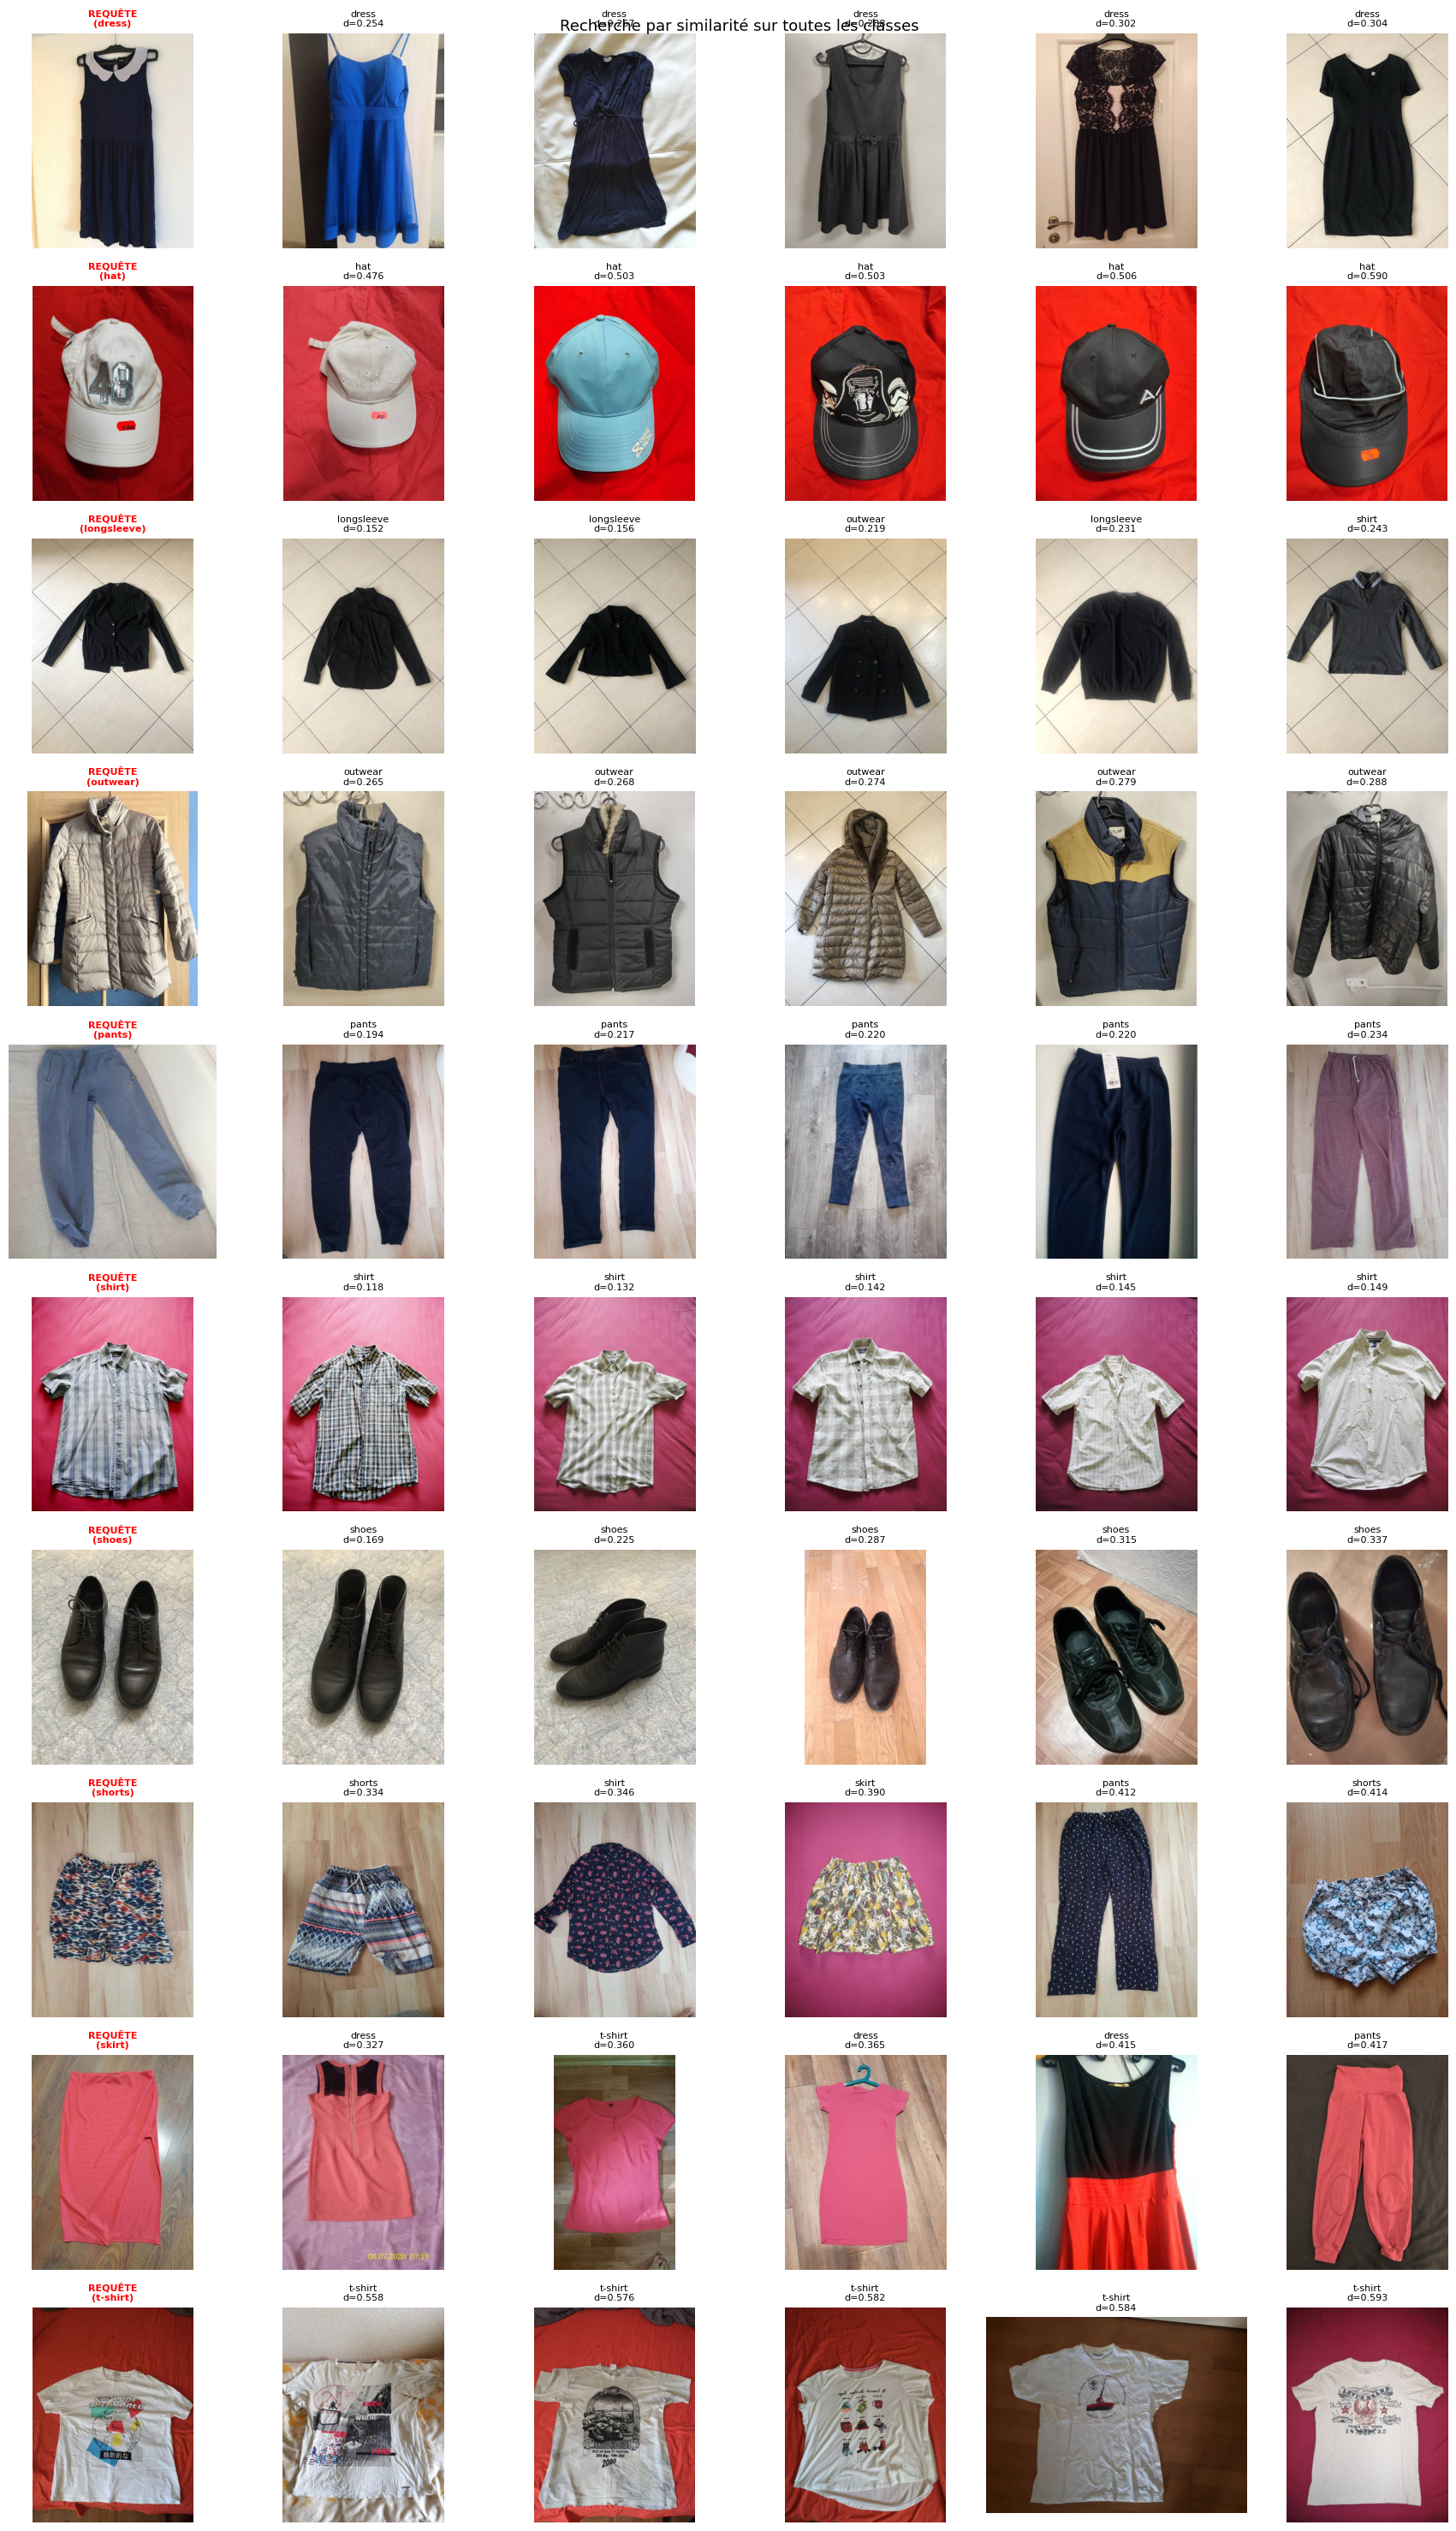

In [33]:
# Test sur une image de chaque classe
fig, axes = plt.subplots(len(classes), 6, figsize=(18, 3*len(classes)))

for row_idx, cls in enumerate(classes):
    query = df_train[df_train["label"] == cls].iloc[0]["path"]
    results = search(query, k=5)

    # Requête
    axes[row_idx, 0].imshow(Image.open(query))
    axes[row_idx, 0].set_title(f"REQUÊTE\n({cls})", fontsize=8,
                                color="red", fontweight="bold")
    axes[row_idx, 0].axis("off")

    # Résultats
    for col_idx, r in enumerate(results):
        axes[row_idx, col_idx+1].imshow(Image.open(r["path"]))
        axes[row_idx, col_idx+1].set_title(
            f"{r['label']}\nd={r['distance']:.3f}", fontsize=8)
        axes[row_idx, col_idx+1].axis("off")

plt.suptitle("Recherche par similarité sur toutes les classes", fontsize=13)
plt.tight_layout()
plt.savefig("../results/recherche_toutes_classes.png", dpi=150)
plt.show()